# Human-in-the-Loop

Human-in-the-Loop(HITL)는 AI가 모든 작업을 자동으로 처리하지 않고, 중요한 판단이 필요한 지점에서 사람이 검토하거나 결정하도록 하는 방식이다.

다음과 같은 상황에 사람의 개입이 필요하다.

- 결제, 삭제, 이메일 발송처럼 되돌리기 어려운 작업의 승인
- LLM이 생성한 답변이나 문서의 검토와 수정
- 작업에 필요한 정보가 부족할 때 추가 입력 요청

```text
AI 작업 수행 → 사람의 판단이 필요한 지점에서 중단 → 검토·입력 → 작업 재개
```

LangGraph에서는 그래프 실행을 중단하고, 사람의 입력을 받은 뒤 재개하는 방식으로 HITL을 구현한다.

In [61]:
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt
from IPython.display import Image, display

load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### `interrupt()`

`interrupt(value)`는 노드나 Tool 내부에서 호출할 수 있다. 실행이 해당 코드에 도달하면 그래프를 중단하고 `value`를 호출자에게 반환한다. Checkpointer는 당시의 그래프 state와 중단된 작업을 기록한다. 같은 `thread_id`로 결정을 전달하면 노드나 Tool을 처음부터 다시 실행하고, `interrupt()`가 그 결정을 반환한 뒤 다음 코드로 진행한다.

In [2]:
@tool(parse_docstring=True)
def send_payment(amount: int, recipient: str) -> str:
    """수신자에게 결제를 실행한다.

    Args:
        amount: 결제 금액
        recipient: 수신자 이름
    """
    # 재개 시 Tool이 처음부터 실행되므로 이 메시지는 다시 출력된다.
    print(f"결제 요청 검토: {recipient}, {amount:,}원")

    decision = interrupt(
        {
            "question": "이 결제를 실행하시겠습니까?",
            "tool": "send_payment",
            "args": {"amount": amount, "recipient": recipient},
        }
    )

    if decision["action"] == "reject":
        reason = decision.get("reason", "사유 없음")
        return f"결제가 취소되었습니다. 사유: {reason}"

    # 결제처럼 부작용이 있는 작업은 interrupt() 뒤에서 실행한다.
    return f"{recipient}에게 {amount:,}원 결제 완료."

### 그래프 구성

Agent가 Tool 호출을 만들면 `ToolNode`가 해당 Tool을 실행한다. `send_payment`는 함수 내부의 `interrupt()`에서 중단된다. 그래프 state와 중단된 작업을 기록하는 Checkpointer, 실행을 구분하는 `thread_id`가 있어야 나중에 재개할 수 있다.

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


tools = [send_payment]
llm = ChatGoogleGenerativeAI(model=MODEL_NAME).bind_tools(tools)


def agent(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

graph = builder.compile(checkpointer=MemorySaver())

### 중단에 사용되는 세 가지 값

| 구분 | 역할 |
|------|------|
| 그래프 state | 노드들이 읽고 수정하는 내부 실행 상태 |
| interrupt payload | 호출자가 검토할 질문, Tool 이름과 인자 |
| resume value | 승인자가 그래프에 돌려주는 결정 |

`interrupt(value)`의 `value`는 `__interrupt__`를 통해 호출자에게 전달된다. payload와 resume 값에는 Checkpointer가 저장할 수 있는 문자열, 숫자, 목록, 딕셔너리 같은 JSON 직렬화 가능 값을 사용한다.

```text
첫 번째 요청: graph.invoke(작업, config)
             → Tool 내부 interrupt()에서 중단
             → payload 반환 및 그래프 실행 정보 기록

두 번째 요청: graph.invoke(Command(resume=결정), 같은 config)
             → 같은 thread_id의 상태 복원
             → 결정이 interrupt()의 반환값이 되어 실행 재개
```

### Tool 실행 전 중단

첫 번째 `invoke()`는 결제를 실행하지 않는다. `send_payment`의 `interrupt()`가 전달한 질문과 Tool 인자가 `__interrupt__`에 담겨 반환된다. Checkpointer에는 그래프 state와 중단된 작업이 기록된다.

In [4]:
config = {"configurable": {"thread_id": "payment-1"}}

result = graph.invoke(
    {"messages": [("user", "홍길동에게 50000원 결제해줘")]},
    config,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"Tool: {request['tool']}")
print(f"인자: {request['args']}")
print(f"다음 노드: {graph.get_state(config).next}")

결제 요청 검토: 홍길동, 50,000원
질문: 이 결제를 실행하시겠습니까?
Tool: send_payment
인자: {'amount': 50000, 'recipient': '홍길동'}
다음 노드: ('tools',)


### 승인 값으로 재개

승인자는 웹 화면이나 API 등을 통해 결정을 내린다. 호출자는 같은 `thread_id`와 `Command(resume=...)`를 사용해 그 결정을 전달한다. `resume` 값은 Tool 내부 `interrupt()`의 반환값이 된다.

재개할 때 `ToolNode`와 Tool 함수는 처음부터 다시 실행되지만, `interrupt()`는 다시 중단하지 않고 전달받은 값을 반환한다.

In [5]:
result = graph.invoke(
    Command(resume={"action": "approve"}),
    config,
)

print(result["messages"][-1].text)

결제 요청 검토: 홍길동, 50,000원
홍길동님에게 50,000원 결제가 완료되었습니다.


### 거절과 사유 전달

새로운 실행을 중단한 뒤 `resume` 값에 `reject`와 사유를 담아 전달하면 Tool이 결제를 수행하지 않고 취소 결과를 반환한다.

In [6]:
config2 = {"configurable": {"thread_id": "payment-2"}}

result = graph.invoke(
    {"messages": [("user", "김철수에게 100000원 결제해줘")]},
    config2,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"Tool: {request['tool']}")
print(f"인자: {request['args']}")
print(f"다음 노드: {graph.get_state(config2).next}")

결제 요청 검토: 김철수, 100,000원
질문: 이 결제를 실행하시겠습니까?
Tool: send_payment
인자: {'amount': 100000, 'recipient': '김철수'}
다음 노드: ('tools',)


In [7]:
result = graph.invoke(
    Command(
        resume={"action": "reject", "reason": "금액을 다시 확인해야 합니다."}
    ),
    config2,
)

print(result["messages"][-1].text)

결제 요청 검토: 김철수, 100,000원
김철수님에게 100,000원 결제 요청을 진행했으나, "금액을 다시 확인해야 합니다"라는 사유로 결제가 취소되었습니다. 결제 금액을 다시 확인한 후 시도해 주세요.


### 직접 승인 또는 거절하기

`input()`으로 승인 여부를 입력하고 중단된 그래프를 재개한다. 실제 서비스에서는 웹 화면이나 API로 결정을 전달한다.

In [ ]:
input_config = {"configurable": {"thread_id": "payment-input"}}

result = graph.invoke(
    {"messages": [("user", "이영희에게 70000원 결제해줘")]},
    input_config,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"인자: {request['args']}")

answer = input("결제를 승인하시겠습니까? (y/n): ").strip().lower()

if answer == "y":
    decision = {"action": "approve"}
else:
    reason = input("거절 사유를 입력하세요: ")
    decision = {"action": "reject", "reason": reason}

result = graph.invoke(
    Command(resume=decision),
    input_config,
)
print(result["messages"][-1].text)

### 서버에서의 요청 흐름

실제 서비스에서는 서버가 승인될 때까지 하나의 요청을 계속 연결해 두지 않는다. 첫 번째 API 요청은 `interrupt()`에서 중단된 정보와 `thread_id`를 응답하고 종료된다. 사용자가 화면에서 승인하거나 거절하면 두 번째 API 요청이 같은 `thread_id`와 `Command(resume=...)`를 전달해 저장된 실행을 재개한다.
```text
Client                              Server / Graph
  │
  │  POST /chat
  │  { message: "..." }
  ├──────────────────────────────────▶
  │                                   │ Graph 실행
  │                                   │ thread_id = "abc123"
  │                                   │ ↓
  │                                   │ interrupt(...)
  │                                   │ ⏸ 실행 중단
  │
  │  response
  │  {
  │    thread_id: "abc123",
  │    interrupt: {
  │      question: "이 작업을 실행할까요?"
  │    }
  │  }
  ◀───────────────────────────────────┤
  │
  │  thread_id = "abc123" 저장
  │
  │  사용자에게 확인 UI 표시
  │
  │    [승인] [거절]
  │
  │  POST /resume
  │  {
  │    thread_id: "abc123",
  │    action: "approve",        ← 승인
  │    // action: "reject"       ← 거절
  │  }
  ├──────────────────────────────────▶
  │                                   │ thread_id로
  │                                   │ 중단된 Graph 식별
  │                                   │ ↓
  │                                   │ Command(
  │                                   │   resume={...}
  │                                   │ )
  │                                   │ ↓
  │                                   │ 실행 재개
  │                                   │ ↓
  │                                   │ action에 따라 분기
  │                                   │ ↓
  │                                   │ Graph 완료
  │
  │  response
  │  "처리가 완료되었습니다."
  ◀───────────────────────────────────┤
  ```

### 실습: 게시글 발행 승인하기

`publish_post(title, content)` Tool을 만들고, 게시글을 발행하기 전에 사용자의 승인을 받는 흐름을 구현한다. 승인과 거절을 각각 실행해 결과를 확인한다.

In [34]:
@tool
def publish_post(title: str, content: str) -> str:
    """사용자가 게시글 발행을 요청할 때 사용한다.

    게시글을 실제로 발행하기 전에 사용자 승인을 요청한다.
    Args:
        title: 발행할 게시글 제목
        content: 발행할 게시글 내용
    """
    print(f"게시글 발행 요청 검토 - 제목 : {title}")

    decision = interrupt(
        {
            "question" : "이 글을 발행하시겠습니까?",
            "tool" : "publish_post",
            "args" : {"title" : title, "content" : content}
        }
    )

    if decision["action"] == "reject":
        reason = decision.get("reason", "사유 없음")
        return f"발행이 취소되었습니다. 사유 : {reason}"
    return f"{title}글이 발행되었습니다."


In [35]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


tools = [publish_post]
llm = ChatGoogleGenerativeAI(model=MODEL_NAME).bind_tools(tools)


def agent(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

graph = builder.compile(checkpointer=MemorySaver())

In [26]:
config = {"configurable": {"thread_id": "publish-1"}}

result = graph.invoke(
    {"messages": [("user", 
                   "publish_post 도구를 사용해서 제목은 '테스트',"
                   "내용은 '오늘 날씨가 좋다'인 게시글을 발행해줘.",)]},
    config,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"Tool: {request['tool']}")
print(f"인자: {request['args']}")
print(f"다음 노드: {graph.get_state(config).next}")

게시글 발행 요청 검토 : 제목 : 오늘 날씨가 좋다
질문: 이 글을 발행하시겠습니까?
Tool: publish_post
인자: {'title': '테스트', 'content': '오늘 날씨가 좋다'}
다음 노드: ('tools',)


In [37]:
input_config = {"configurable": {"thread_id": "publish-1"}}

result = graph.invoke(
    {"messages": [("user", 
                   "publish_post 도구를 사용해서 제목은 '테스트',"
                   "내용은 '오늘 날씨가 좋다'인 게시글을 발행해줘.",)]},
    input_config,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"인자: {request['args']}")

answer = input("발행을 승인하겠습니까? (y/n): ").strip().lower()

if answer == "y":
    decision = {"action": "approve"}
else:
    reason = input("거절 사유를 입력하세요: ")
    decision = {"action": "reject", "reason": reason}

result = graph.invoke(
    Command(resume=decision),
    input_config,
)
print(result["messages"][-1].text)

게시글 발행 요청 검토 - 제목 : 테스트
질문: 이 글을 발행하시겠습니까?
인자: {'title': '테스트', 'content': '오늘 날씨가 좋다'}
게시글 발행 요청 검토 - 제목 : 테스트
게시글이 성공적으로 발행되었습니다!

* **제목:** 테스트
* **내용:** 오늘 날씨가 좋다


In [76]:
## 강사님 풀이
@tool
def publish_post(title: str, content: str) -> str:
    """게시글을 발행한다."""
    # TODO: 게시글 발행 전 승인을 받는 HITL 흐름을 구현하세요.
    print('게시글 발행 검토를 해주세요.')
    decision = interrupt(
        {
            "question": "이 게시글을 공개하겠습니까?",
            "tool": "publish_post",
            "args": {"title": title, "content": content},
        }
    )


    if decision['action'] == 'approve':
        return ('게시글 발행 성공!')

    elif decision['action'] == 'reject':
        return ('게시글 발행 실패!')


In [77]:
from langchain.agents import create_agent
tools = [publish_post]
agent = create_agent(model=llm, tools=tools, checkpointer=MemorySaver())

In [78]:
# 1. invoke()
thread_id = "thread-2"
config = {"configurable": {"thread_id": thread_id}}

result = agent.invoke({"messages": [("human", "점심식사에 대한 게시글을 발행해줘.")]}, config=config)

print(result["__interrupt__"][0].value)

# 2. 결과가 interupt되어서 우리에게 다시 되묻는 과정이 있다.

게시글 발행 검토를 해주세요.
{'question': '이 게시글을 공개하겠습니까?', 'tool': 'publish_post', 'args': {'title': '오늘의 점심 식사 일기 & 메뉴 추천', 'content': '오늘 점심은 맛있는 메뉴로 즐겁고 에너지를 충전하는 한 끼였습니다. 다들 오늘 점심으로 어떤 음식 드셨나요? 맛있는 점심 식사 후 가벼운 산책으로 남은 하루도 활기차게 보내세요!'}}


In [79]:
user_input = input('할꺼면 - y, 안할꺼면 - n')

# 승인
if user_input == 'y':
    action = 'approve'

# 거절
elif user_input == 'n':
    action = 'reject'

result = agent.invoke(Command(resume={'action' : action}), config=config)

print(result)

게시글 발행 검토를 해주세요.
{'messages': [HumanMessage(content='점심식사에 대한 게시글을 발행해줘.', additional_kwargs={}, response_metadata={}, id='0eacd20d-9257-4944-95f6-e64ba965608d'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'publish_post', 'arguments': '{"title": "\\uc624\\ub298\\uc758 \\uc810\\uc2ec \\uc2dd\\uc0ac \\uc77c\\uae30 & \\uba54\\ub274 \\ucd94\\ucc9c", "content": "\\uc624\\ub298 \\uc810\\uc2ec\\uc740 \\ub9db\\uc788\\ub294 \\uba54\\ub274\\ub85c \\uc990\\uac81\\uace0 \\uc5d0\\ub108\\uc9c0\\ub97c \\ucda9\\uc804\\ud558\\ub294 \\ud55c \\ub07c\\uc600\\uc2b5\\ub2c8\\ub2e4. \\ub2e4\\ub4e4 \\uc624\\ub298 \\uc810\\uc2ec\\uc73c\\ub85c \\uc5b4\\ub5a4 \\uc74c\\uc2dd \\ub4dc\\uc168\\ub098\\uc694? \\ub9db\\uc788\\ub294 \\uc810\\uc2ec \\uc2dd\\uc0ac \\ud6c4 \\uac00\\ubcbc\\uc6b4 \\uc0b0\\ucc45\\uc73c\\ub85c \\ub0a8\\uc740 \\ud558\\ub8e8\\ub3c4 \\ud65c\\uae30\\ucc28\\uac8c \\ubcf4\\ub0b4\\uc138\\uc694!"}'}, '__gemini_function_call_thought_signatures__': {'call_564089': 'EuwICukIARFNMg/

### 추가 실습: 실행 계획 검토하기

아래 코드는 HITL을 추가할 수 있도록 실행 과정을 단순화한 Plan-and-Execute 그래프다.

Planner가 만든 계획을 실행 전에 검토한다. 승인하면 Executor가 계획을 실행하고, 거절하면 추가 의견을 Planner에 전달해 계획을 다시 만든다. 수정된 계획은 다시 검토받는다.

```text
Planner → 계획 검토(HITL)
            ├─ 승인 → Executor
            └─ 거절 + 추가 의견 → Planner → 계획 검토(HITL)
```

In [38]:
import operator
from typing import Literal

from pydantic import BaseModel, Field
from langgraph.graph import END


class SimplePlanState(TypedDict):
    task: str
    plan: list[str]
    completed: Annotated[list[str], operator.add]


class SimplePlan(BaseModel):
    steps: list[str] = Field(description="순서대로 수행할 단계")


simple_planner = ChatGoogleGenerativeAI(model=MODEL_NAME).with_structured_output(SimplePlan)


def simple_plan_step(state: SimplePlanState):
    result = simple_planner.invoke(
        f"{state['task']}\n실행 계획을 3단계 이내로 작성하세요."
    )
    return {"plan": result.steps}


def simple_execute_step(state: SimplePlanState):
    step = state["plan"][0]
    return {
        "plan": state["plan"][1:],
        "completed": [f"완료: {step}"],
    }


def route_execution(state: SimplePlanState):
    return "continue" if state["plan"] else "end"

def review_step(state: SimplePlanState):
    """ Planner가 만든 계획을 실행 전에 검토한다.
    """
    decision = interrupt(
        {
            "question" : "이 계획을 승인하겠습니까?",
            "plan" : state["plan"]
        }
    )
    return decision["action"]




base_builder = StateGraph(SimplePlanState)
base_builder.add_node("planner", simple_plan_step)
base_builder.add_node("executor", simple_execute_step)
base_builder.add_edge(START, "planner")

base_builder.add_conditional_edges(
    "planner",
    review_step,
    {
        "approve" : "executor",
        "reject" : "planner"
    }
)
base_builder.add_conditional_edges(
    "executor",
    route_execution,
    {"continue": "executor", "end": END},
)

hitl_graph = base_builder.compile(checkpointer=MemorySaver())

In [42]:
config = {"configurable": {"thread_id": "plan-review"}}

result = hitl_graph.invoke(
    {"task": "팀 회의 준비하기"},
    config,
)

print(result["__interrupt__"][0].value)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'question': '이 계획을 승인하겠습니까?', 'plan': ['회의 목적 및 안건을 설정합니다.', '회의 일정과 장소를 확정하고 참석자에게 알림을 보냅니다.', '회의에 필요한 자료를 작성하고 사전 공유합니다.']}


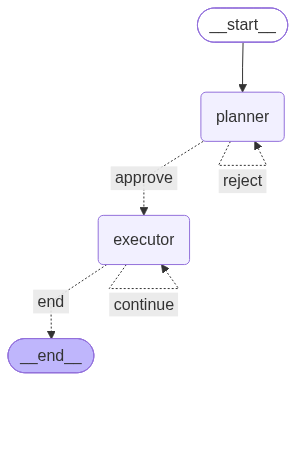

In [ ]:
# TODO: Plan-and-Execute 그래프에 HITL을 추가하세요.

import operator
from typing import Literal

from pydantic import BaseModel, Field
from langgraph.graph import END


class SimplePlanState(TypedDict):
    task: str
    plan: list[str]
    completed: Annotated[list[str], operator.add]
    feedback: str


class SimplePlan(BaseModel):
    steps: list[str] = Field(description="순서대로 수행할 단계")


simple_planner = ChatGoogleGenerativeAI(model=MODEL_NAME).with_structured_output(SimplePlan)


def simple_plan_step(state: SimplePlanState):
    feedback = state.get("feedback", "")
    result = simple_planner.invoke(
        f"사용자 의견 : {feedback}\n"
        f"{state['task']}\n실행 계획을 3단계 이내로 작성하세요."
    )
    return {"plan": result.steps}


def simple_execute_step(state: SimplePlanState):
    step = state["plan"][0]
    return {
        "plan": state["plan"][1:],
        "completed": [f"완료: {step}"],
    }


def route_execution(state: SimplePlanState):
    return "continue" if state["plan"] else "end"

def review_step(state: SimplePlanState):
    """ Planner가 만든 계획을 실행 전에 검토한다.
    """
    decision = interrupt(
        {
            "question" : "이 계획을 승인하겠습니까?",
            "plan" : state["plan"]
        }
    )
    return decision["action"]




base_builder = StateGraph(SimplePlanState)
base_builder.add_node("planner", simple_plan_step)
base_builder.add_node("executor", simple_execute_step)
base_builder.add_edge(START, "planner")

base_builder.add_conditional_edges(
    "planner",
    review_step,
    {
        "approve" : "executor",
        "reject" : "planner"
    }
)
base_builder.add_conditional_edges(
    "executor",
    route_execution,
    {"continue": "executor", "end": END},
)

hitl_graph = base_builder.compile(checkpointer=MemorySaver())

display(Image(hitl_graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "plan-feedback-1"}}

result = hitl_graph.invoke(
    {"task": "팀 회의 준비하기"},
    config,
)

print(result["__interrupt__"][0].value)
a = result["__interrupt__"][0].value
question = a['question']

{'question': '이 계획을 승인하겠습니까?', 'plan': ['회의 안건 및 목표 설정하기', '필요한 회의 자료 작성 및 사전 공유하기', '회의 시간, 장소 및 참석자 안내하기']}


### 실행

HITL을 추가한 그래프를 실행해 초기 계획을 확인한다.

추가 의견을 전달하고 수정된 계획을 확인한다.

In [58]:
answer = input("이 계획을 승인하겠습니까? y/n").strip().lower()

if answer == "y":
    command = Command(
        resume={"action" : "approve"}
    )
else:
    feedback = input("수정 의견을 입력하세요 : ")

    command = Command(
        resume={"action" : "reject"},
        update={"feedback" : feedback}
    )
result = hitl_graph.invoke(command, config)

if "__interrupt__" in result:
    print(result["__interrupt__"][0].value)
else:
    print(*result["completed"], sep="\n")

{'question': '이 계획을 승인하겠습니까?', 'plan': ['사용자 불만족 피드백 데이터 수집 및 주요 문제점 분석', '개선 대안 도출을 위한 회의 안건 및 논의 자료 준비', '팀원들에게 관련 자료 및 안건 공유 후 회의 일정 확정']}


수정된 계획을 승인하고 실행 결과를 확인한다.

In [59]:
result = hitl_graph.invoke(
    Command(resume={"action": "approve"}),
    config,
)

print(*result["completed"], sep="\n")

완료: 피드백의 구체적인 원인 분석 및 개선 필요 사항 정리
완료: 문제 해결을 위한 대안 및 개선 아이디어 도출
완료: 회의 안건 작성 및 팀원들과 공유하여 논의 진행


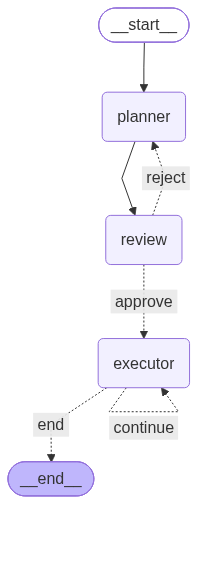

In [ ]:
## 다시!

# TODO: Plan-and-Execute 그래프에 HITL을 추가하세요.

import operator
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import END


class SimplePlanState(TypedDict):
    task: str
    plan: list[str]
    completed: Annotated[list[str], operator.add]
    feedback: str
    review_action: str


class SimplePlan(BaseModel):
    steps: list[str] = Field(description="순서대로 수행할 단계")


simple_planner = ChatGoogleGenerativeAI(model=MODEL_NAME).with_structured_output(SimplePlan)


def simple_plan_step(state: SimplePlanState):
    feedback = state.get("feedback", "")
    result = simple_planner.invoke(
        f"사용자 의견 : {feedback}\n"
        f"{state['task']}\n실행 계획을 3단계 이내로 작성하세요."
    )
    return {"plan": result.steps}


def simple_execute_step(state: SimplePlanState):
    step = state["plan"][0]
    return {
        "plan": state["plan"][1:],
        "completed": [f"완료: {step}"],
    }


def route_execution(state: SimplePlanState):
    return "continue" if state["plan"] else "end"

def review_step(state: SimplePlanState):
    """ Planner가 만든 계획을 실행 전에 검토한다.
    """
    decision = interrupt(
        {
            "question" : "이 계획을 승인하겠습니까?",
            "plan" : state["plan"]
        }
    )
    return {
        "review_action" : decision["action"],
        "feedback" : decision.get("feedback", "")
        }

def route_review(state: SimplePlanState):
    return state["review_action"]


base_builder = StateGraph(SimplePlanState)
base_builder.add_node("planner", simple_plan_step)
base_builder.add_node("review", review_step)
base_builder.add_node("executor", simple_execute_step)
base_builder.add_edge(START, "planner")
base_builder.add_edge("planner", "review")

base_builder.add_conditional_edges(
    "review",
    route_review,
    {
        "approve" : "executor",
        "reject" : "planner"
    }
)
base_builder.add_conditional_edges(
    "executor",
    route_execution,
    {"continue": "executor", "end": END},
)

hitl_graph = base_builder.compile(checkpointer=MemorySaver())

display(Image(hitl_graph.get_graph().draw_mermaid_png()))

In [66]:
config = {"configurable": {"thread_id": "plan-feedback-node-1"}}

result = hitl_graph.invoke(
    {"task": "팀 회의 준비하기"},
    config,
)

request = result["__interrupt__"][0].value

print(request["question"])
print(request["plan"])

이 계획을 승인하겠습니까?
['회의 안건 및 목표 설정하기', '회의 일정 및 장소 확정 후 참석자에게 공유하기', '필요한 회의 자료 작성 및 사전 배포하기']


In [68]:
config = {"configurable": {"thread_id": "plan-feedback-loop-1"}}

task = input("무슨 일을 계획할까요?: ")

result = hitl_graph.invoke(
    {"task": task},
    config,
)

while "__interrupt__" in result:
    request = result["__interrupt__"][0].value

    print("\n" + request["question"])
    for i, step in enumerate(request["plan"], 1):
        print(f"{i}. {step}")

    answer = input("승인하면 y, 수정하려면 n: ").strip().lower()

    if answer == "y":
        command = Command(
            resume={"action": "approve"}
        )
    else:
        feedback = input("수정 의견을 입력하세요: ")
        command = Command(
            resume={
                "action": "reject",
                "feedback": feedback,
            }
        )

    result = hitl_graph.invoke(command, config)

print("\n실행 결과")
print(*result["completed"], sep="\n")


이 계획을 승인하겠습니까?
1. 야식 메뉴를 선정하고 배달 앱이나 냉장고 재고를 확인합니다.
2. 음식을 주문하거나 직접 간단하게 조리합니다.
3. 음식을 맛있게 먹은 후 분리수거 및 뒷정리를 합니다.

이 계획을 승인하겠습니까?
1. 현재 선호하는 맛과 소화 상태를 확인합니다.
2. 부담 없이 즐길 수 있는 야식 메뉴 후보 3가지를 선정합니다.
3. 최종 추천 메뉴와 함께 간단한 조리법 또는 주문 팁을 제공합니다.

이 계획을 승인하겠습니까?
1. 선호하는 야식 스타일과 예산을 확인하여 종류(매운맛, 기름진 맛, 가벼운 맛 등) 파악하기
2. 배달 앱 및 근처 매장의 대표 야식 메뉴(치킨, 족발, 떡볶이 등) 후보 선정하기
3. 최종 야식 메뉴를 결정하고 주문 진행하기

실행 결과
완료: 오늘 해야 할 일 목록을 작성하고 우선순위 정하기
완료: 우선순위에 따라 시간대별 세부 실행 계획 수립하기
완료: 계획에 맞춰 할 일을 진행하고 마감 전 점검하기
완료: 선호하는 야식 스타일과 예산을 확인하여 종류(매운맛, 기름진 맛, 가벼운 맛 등) 파악하기
완료: 배달 앱 및 근처 매장의 대표 야식 메뉴(치킨, 족발, 떡볶이 등) 후보 선정하기
완료: 최종 야식 메뉴를 결정하고 주문 진행하기


In [ ]:
## 강사님 풀이!

import operator
from typing import Literal

from pydantic import BaseModel, Field
from langgraph.graph import END


class SimplePlanState(TypedDict):
    task: str
    plan: list[str]
    completed: Annotated[list[str], operator.add]
    action: str
    feedback: str

class SimplePlan(BaseModel):
    steps: list[str] = Field(description="순서대로 수행할 단계")


simple_planner = ChatGoogleGenerativeAI(model=MODEL_NAME).with_structured_output(SimplePlan)


def simple_plan_step(state: SimplePlanState):
    task = state['task']
    if state.get('feedback'):
        task += f'기존 계획 : {state.get('plan')} 다음 피드백을 바탕으로 작성해줘. {state.get('feedback')}'
    result = simple_planner.invoke(
        f"{task}\n실행 계획을 3단계 이내로 작성하세요."
    )
    return {"plan": result.steps}


def simple_execute_step(state: SimplePlanState):
    step = state["plan"][0]
    return {
        "plan": state["plan"][1:],
        "completed": [f"완료: {step}"],
    }


def route_execution(state: SimplePlanState):
    return "continue" if state["plan"] else "end"

####################

def human_approval(state: SimplePlanState):
    # interrupt해서 사용자한테 해당 plan을 지속할건지, 재작성 할건지 정함.
    decision = interrupt({
        # 사용자한테 전달할 정보.
        'plan' : state['plan'],
        'question' : "이 계획으로 실행할까요?"

    })
    return {
        'action' : decision['action'], 
        'feedback' : decision.get('feedback', "")
        }

def route_human_appoval(state: SimplePlanState):
    # 사용자가 interrupt한 부분에 대해서
    # 결정지은 값에 대해서 execute할건지 다시 plan할건지 정하는 router.
    action = state['action']

    if action == 'edit':
        return 'edit'
    return 'approve'

base_builder = StateGraph(SimplePlanState)
base_builder.add_node("planner", simple_plan_step)
base_builder.add_node("executor", simple_execute_step)
base_builder.add_node("approval", human_approval)

base_builder.add_edge(START, "planner")
base_builder.add_edge("planner", "approval")
base_builder.add_conditional_edges(
    "approval",
    route_human_appoval,
    {
        'edit' : 'planner',
        'approve' : 'executor'
    }
)

base_builder.add_conditional_edges(
    "executor",
    route_execution,
    {"continue": "executor", "end": END},
)

hitl_graph = base_builder.compile(checkpointer=MemorySaver())

from IPython.display import Image, display

display(Image(hitl_graph.get_graph().draw_mermaid_png()))

In [ ]:
result = hitl_graph.invoke(
    {
        "task": "팀 회의 준비하기"
    }
)
print(*result["completed"], sep="\n")

In [ ]:
config = {"configurable": {"thread_id": "plan-review-2"}}

result = hitl_graph.invoke(
    {
        "task": "팀 회의 준비하기"
    },
    config
)
print(result["__interrupt__"][0].value)

In [ ]:
result = hitl_graph.invoke(
    Command(
        resume={
            'action' : 'edit',
            'feedback' : input()
        }
    ),
    config,
)
print(result["__interrupt__"][0].value)

In [ ]:
result = hitl_graph.invoke(
    Command(resume={
        'action' : 'approve'
    }),
    config,
)
print(*result["completed"], sep="\n")

### 추가 실습: 필요한 정보 질문하기

사용자 요청에 필요한 정보가 부족할 때 LLM이 추가 질문을 생성하는 흐름을 구현한다. 각 질문에는 객관식 선택지를 제공하고, 사용자가 직접 답변할 수도 있도록 한다. 답변을 받은 뒤에는 원래 요청을 수행하는 대신 사용자 답변을 정리한다.

- 예시 요청: 다음 주말 국내 여행을 계획하고 있습니다. 제 취향에 맞는 1박 2일 일정을 추천해 주세요.
- 예시 요청: 퇴근 후에 실천할 수 있는 운동 루틴을 제 상황에 맞게 추천해 주세요.

In [70]:
class Question(BaseModel):
    id: str
    question: str
    choices: list[str]

class ListQuestion(BaseModel):
    questions: list[Question]

class State(TypedDict):
    request: str
    questions: list[dict]
    answer: dict
    summary: str

llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

llm_with_question_output = llm.with_structured_output(ListQuestion)


def ask_question(state: State):
    request = state['request']

    result = llm_with_question_output.invoke(
        f"""
    {request} 요청을 보고 이 요청을 제대로 처리하기 위해 추가적으로 필요한 정보를 만들어.
    질문은 3개이내로 만들고, 각 질문에는 객관식 선택지 3개를 제공해.
    사용자가 직접 답변할 수도 있으니 선택지는 참고용으로 작성
    """
    )

    questions = [q.model_dump() for q in result.questions]

    answer = interrupt(
        {
            "message": "요청을 처리하기 위해 추가 정보가 필요합니다.",
            "questions": questions
        }
    )
    return {
        "questions" : questions,
        "answer" : answer
    }

def summarize_answer(state: State):
    request = state['request']
    questions = state['questions']
    answer = state['answer']

    response = llm.invoke(f"""
    {request}, {questions}, {answer}을 보고 사용자 답변을 정리해줘. 
    """)
    return {"summary" : response.text}


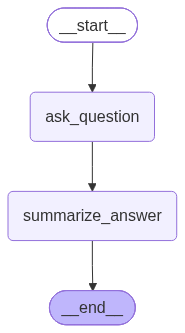

In [71]:
builder = StateGraph(State)

builder.add_node("ask_question", ask_question)
builder.add_node("summarize_answer", summarize_answer)

builder.add_edge(START, "ask_question")
builder.add_edge("ask_question", "summarize_answer")
builder.add_edge("summarize_answer", END)

graph = builder.compile(checkpointer=MemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
config = {"configurable": {"thread_id": "question-1"}}

result = graph.invoke(
    {
        "request": "다음 주말 국내 여행을 계획하고 있습니다. 제 취향에 맞는 1박 2일 일정을 추천해 주세요."
    },
    config,
)

request = result["__interrupt__"][0].value
print(request["message"])
# print(request["questions"])

for q in request["questions"]:
    print(q["id"])
    print(q["question"])
    print(q["choices"])

요청을 처리하기 위해 추가 정보가 필요합니다.
q1
선호하는 여행 스타일은 무엇인가요?
['힐링 및 휴식 (자연, 스파 등)', '액티비티 및 체험 (등산, 테마파크 등)', '식도락 및 문화 탐방 (맛집, 미술관 등)']
q2
누구와 함께 떠나는 여행인가요?
['혼자 떠나는 여행', '연인 또는 친구와 함께', '가족(아이 또는 부모님)과 함께']
q3
주요 이동 수단과 선호하는 거리는 어떻게 되나요?
['대중교통 이용 / 수도권 및 주요 도시 근교', '자차 이용 / 출발지 기준 2시간 이내', '자차/KTX/비행기 이용 / 거리에 상관없이 어디든']


In [81]:
result = graph.invoke(
    Command(
        resume={
            "1": "힐링 및 자연",
            "2": "수도권 출발 / 차로 2시간 이내",
            "3": "연인 또는 친구와 함께",
        }
    ),
    config,
)

print(result["summary"])

제시해주신 답변을 바탕으로 정리한 사용자의 여행 취향은 다음과 같습니다.

* **여행 테마:** 힐링 및 자연 속 휴식
* **이동 수단 및 거리:** 자차 이용 (수도권 출발 / 2시간 이내 근교)
* **동반자:** 연인 또는 친구
